# Training Baseline (Refactorizado)

Notebook reutilizable que ejecuta únicamente llamadas a funciones definidas en `src/`.

## 1) Imports y configuración básica

In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim

# Asegurar que la raíz del repo está en sys.path (notebook ubicado en `baseline/`)
sys.path.append(str(Path("..").resolve()))

from src import (
    CONFIG,
    CATALOG_PATH,
    FITS_DIR,
    build_resnet18,
    build_dataloaders,
    calculate_class_weights,
    compute_classification_metrics,
    create_model_dir,
    evaluate_and_save,
    generate_gradcam_visualization,
    load_catalog,
    save_learning_curves,
    save_training_checkpoint,
    save_training_metadata,
    set_global_seed,
    split_catalog,
    train_loop,
    get_device,
)

print("Imports OK")

Imports OK


## 2) Semilla y dispositivo

In [2]:
set_global_seed(CONFIG["seed"])
device = get_device()
print(f"Using device: {device}")

Using device: cuda


## 3) Carga del catálogo y división estratificada

In [3]:
from pathlib import Path

catalog_path = Path(CATALOG_PATH)
report_path = Path("..") / "data" / "processed" / "dataset_validation_report.csv"

df = load_catalog(catalog_path, report_path=report_path)
train_df, val_df, test_df = split_catalog(df, seed=CONFIG["seed"])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 5868 | Val: 1258 | Test: 1258


## 4) Datasets y DataLoaders

In [4]:
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_dataloaders(
    train_df,
    val_df,
    test_df,
    FITS_DIR,
    CONFIG,
)

print("Datasets and DataLoaders ready")

Datasets and DataLoaders ready


## 5) Construcción del modelo (ResNet18)

In [5]:
model_name = "resnet18_baseline"
model, trainable_params, frozen_params = build_resnet18(
    num_classes=CONFIG["num_classes"],
    pretrained=True,
    freeze_backbone=CONFIG.get("freeze_backbone", True),
    device=device,
)

print(f"Trainable params: {trainable_params:,} | Frozen params: {frozen_params:,}")

Trainable params: 65,922 | Frozen params: 11,176,512


## 6) Pérdida y optimizador

In [6]:
class_weights = calculate_class_weights(train_df, CONFIG["num_classes"], device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

print("Criterion and optimizer ready")

Criterion and optimizer ready


## 7) Entrenamiento y guardado de artefactos

In [7]:
model_dir = create_model_dir(model_name)
checkpoint_path = model_dir / "checkpoint.pth"
history_path = model_dir / "history.json"

if checkpoint_path.exists() and history_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    history = checkpoint.get("history", {})
    print(f"Loaded existing checkpoint from {checkpoint_path}")
else:
    model, history = train_loop(model, train_loader, val_loader, criterion, optimizer, device, epochs=CONFIG["epochs"])
    save_training_checkpoint(
        model,
        optimizer,
        history,
        CONFIG,
        class_weights,
        trainable_params,
        frozen_params,
        model_dir,
    )

training_meta = {
    "model_name": model_name,
    "epochs": CONFIG["epochs"],
    "config": CONFIG,
    "trainable_params": trainable_params,
    "frozen_params": frozen_params,
    "dataset_split": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "catalog_path": str(catalog_path),
    "fits_dir": str(FITS_DIR),
    "checkpoint_file": checkpoint_path.name,
    "history_file": history_path.name,
}

save_training_metadata(model_dir, history, training_meta)
print(f"Model artifacts saved under: {model_dir}")

Loaded existing checkpoint from data/models/resnet18_baseline/checkpoint.pth
Model artifacts saved under: data/models/resnet18_baseline


## 8) Evaluación final en Test Set

In [8]:
eval_dir = model_dir / "evaluation"
sample_names = test_df["name"].tolist()
metrics = evaluate_and_save(
    model,
    test_loader,
    device,
    compute_classification_metrics,
    eval_dir,
    sample_names=sample_names,
)

print("Test metrics:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Test metrics:
accuracy: 0.7034976152623211
precision: 0.390625
recall: 0.7662835249042146
f1_score: 0.517464424320828
roc_auc: 0.8094321278010277


## 9) Curvas de aprendizaje

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

Learning curves saved: data/models/resnet18_baseline/learning_curves.png


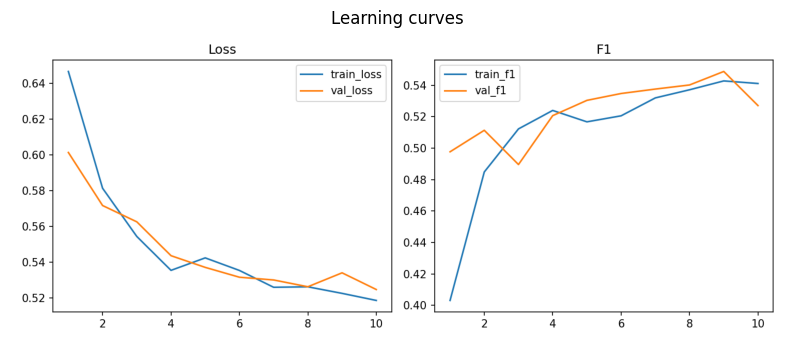

In [12]:
learning_curves_path = save_learning_curves(history, model_dir)
print(f"Learning curves saved: {learning_curves_path}")

img = mpimg.imread(learning_curves_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Learning curves")
plt.show()

## 10) Grad-CAM de ejemplo

Grad-CAM saved: data/models/resnet18_baseline/gradcam/gradcam_positive_label1.png


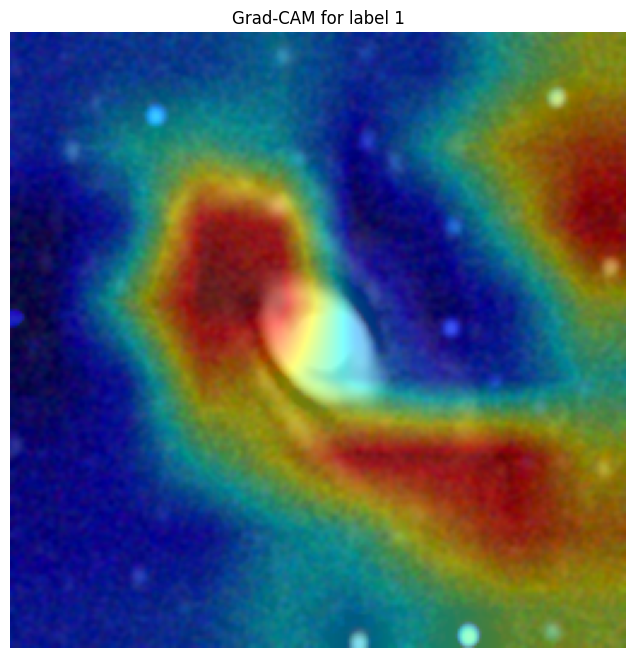

In [13]:
gradcam_dir = model_dir / "gradcam"
gradcam_dir.mkdir(parents=True, exist_ok=True)
gradcam_path = gradcam_dir / "gradcam_positive_label1.png"

saved_path = generate_gradcam_visualization(model, test_dataset, device, target_label=1, save_path=gradcam_path)
print(f"Grad-CAM saved: {saved_path}")

img = mpimg.imread(saved_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Grad-CAM for label 1")
plt.show()

## 11) Notas

- Este notebook no define funciones nuevas: usa utilidades reutilizables dentro de `src/experiment.py`.
- Para reutilizar en otros experimentos, solo cambia `build_resnet18`, `CONFIG` o el nombre de `model_name`.